# Logistic Regression !!

---


**Recitation by Dr. Stephanie Milani**

_Friday, 11:00, 15:30 Office Hours at CDS 506 (For any follow-up questions)_

In these lab sessions, we will be using Jupyter notebooks running on Google Colab, which has most Python libraries installed.

Please make a copy of this notebook in your own Google Drive.


## Quick recap

Previous recitations introduced the elements of a traditional machine learning pipeline through a weather forecasting application in PyTorch.
Today we will first do a partner activity in which we discuss the solutions from the previous recitation. Then we will discuss multi-class classification.
You will have time at the end of the recitation to work on the homework.


## Today's schedule:
1. Pair off and discuss the mandatory solutions. Questions to answer:
    1. What you tried?
    2. What you learned?
    3. Anything weird?
    4. Metrics discussion — why is recall important?
2. Optional assignment. Anyone try it? Anyone have a solution that they want to share?
3. Multi-class classification intro & exercises
4. Optional exercise and/or homework

## Activity 1

Find a partner & share your solutions to last week's exercises. Answer the above questions and record them here. Be prepared to discuss.


*Your answer here.*

## Multi-class classification

In this exercise, we will implement a logistic regression model on multi-class classification. We will use the [Iris](https://scikit-learn.org/stable/datasets/toy_dataset.html#iris-plants-dataset) flower data set which contains different physical properties from three related species of Iris flowers collected by Edgar Anderson. It was first used by British statistician and biologist Ronald Fisher in 1936 for his pioneering study on linear discriminant analysis [1].

<div>
<img src="https://upload.wikimedia.org/wikipedia/commons/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg" width="200"/>
<img src="https://upload.wikimedia.org/wikipedia/commons/4/41/Iris_versicolor_3.jpg" width="200" />
  <img src="https://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg" width="200" />
</div>

*Images from Wikipedia.*

[1] Fisher, R.A. “The use of multiple measurements in taxonomic problems” Annual Eugenics, 7, Part II, 179-188 (1936).

**Goal.** Predict one label from $K$ mutually exclusive classes given features $x \in \mathbb{R}^d$.

**Step 1. Computing linear scores (logits).**
For an input feature vector $x \in \mathbb{R}^d$, we first compute a **linear score** for each class:

$$
z_k = w_k^\top x + b_k \quad \text{for } k = 1, \dots, K
$$

- $w_k$ = weight vector for class $k$ ($wx  \in \mathbb{R}^K$)
- $b_k$ = bias for class $k$ ($b  \in \mathbb{R}^K$)
- $z_k$ = "logit" score (can be any real number) ($z  \in \mathbb{R}^K$)

> Think of these logits like “raw votes” from each class.

---

**Step 2. Converting scores into probabilities.**

To turn scores into probabilities, we use the **softmax function**:

$$
p(y=k \mid x) = \frac{\exp(z_k)}{\sum_{j=1}^K \exp(z_j)}.
$$

- Each probability is between 0 and 1.  
- All probabilities sum to 1.  
- The class with the highest probability is the prediction.

> Intuition: softmax is like stretching the scores into a probability distribution — bigger scores get disproportionately more weight.

---

**Step 3. Training with cross-entropy loss.**

We want the predicted probability of the correct class to be as high as possible.  
So we use the **cross-entropy loss**:

$$
\mathcal{L} = -\log p(y=y^* \mid x).
$$


Cross-entropy essentially measures the similarity between two probability distributions.

> The loss is small if the model assigns high probability to the true label $y^*$, and large otherwise.

---

**Step 4. Decision rule.**

At prediction time, we choose:

$$
\hat{y} = \arg\max_k p(y=k \mid x).
$$


We can load the data set automatically using the [sklearn](https://scikit-learn.org/stable/) library.

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

# ---- Load & dataframe ----
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = pd.Series(iris.target)
df["target_name"] = df["target"].map(dict(enumerate(iris.target_names)))


In [2]:
from sklearn.datasets import load_iris
import pandas as pd

iris_data = load_iris()
df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
df['target'] = pd.Series(iris_data.target)

df


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

X, y = load_iris(return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
)
clf.fit(Xtr, ytr)
print("Accuracy:", accuracy_score(yte, clf.predict(Xte)))


Accuracy: 0.9666666666666667


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [10]:
import torch
from torch import nn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = load_iris(return_X_y=True)
scaler = StandardScaler().fit(X)
X = scaler.transform(X)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
Xtr = torch.tensor(Xtr, dtype=torch.float32)
ytr = torch.tensor(ytr, dtype=torch.long)
Xte = torch.tensor(Xte, dtype=torch.float32)
yte = torch.tensor(yte, dtype=torch.long)

model = nn.Linear(Xtr.shape[1], 3)             # 4→3
criterion = nn.CrossEntropyLoss()               # combines softmax + NLL
opt = torch.optim.SGD(model.parameters(), lr=0.1)

for _ in range(400):
    opt.zero_grad()
    logits = model(Xtr)                         # shape [N, 3]
    loss = criterion(logits, ytr)               # -log p_{y*}
    loss.backward()
    opt.step()

with torch.no_grad():
    preds = model(Xte).argmax(dim=1)
    acc = (preds == yte).float().mean().item()
print("Accuracy:", acc)


Accuracy: 0.9666666388511658


###Exercise 1: Data Analysis
We start with some data analysis.

Please write a short analysis code to count how many samples are there from each class of flower. Plot the count as a bar graph.

target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


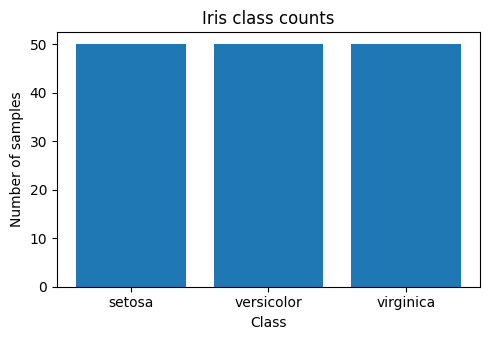

In [12]:
# Count per class + bar plot
import matplotlib.pyplot as plt

# counts in a fixed, readable order
order = ['setosa', 'versicolor', 'virginica']
class_counts = (
    df['target_name']
      .value_counts()
      .reindex(order, fill_value=0)
)

print(class_counts)  # optional: see the numbers

plt.figure(figsize=(5, 3.5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Iris class counts")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


###Exercise 2: Train-test split  
Next, we create a training and testing split. Please process the data to convert to tensors and store as training and testing tensors. Make sure the data is numeric and clean. Note that we also need to define the input and output to our classification model. You can do an 80/20 train-test split.

In [ ]:
## Solution
import torch

# Write data processing and splitting routine


Let's define again a PyTorch Dataset type class to store and easily iterate over the Iris Data Set.

In [13]:
from torch.utils.data import Dataset, DataLoader, RandomSampler

class IrisDataset(Dataset):
  def __init__(self, train_in, train_out):
        # Initialize data
        self.n_samples = train_in.shape[0]
        self.x_data = train_in    # size [n_samples, n_features]
        self.y_data = train_out   # size [n_samples, 1]

  # support indexing such that dataset[i] can be used to get i-th sample
  def __getitem__(self, index):
        return self.x_data[index], self.y_data[index]

  # we can call len(dataset) to return the size
  def __len__(self):
      return self.n_samples

In [14]:
X = iris.data                     # (150, 4)
y = iris.target                   # (150,)

# stratified split keeps class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale features (fit on train only, transform test)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# optional: wrap into datasets/dataloaders
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

# quick sanity prints
X_train_t.shape, y_train_t.shape, X_test_t.shape, y_test_t.shape

(torch.Size([120, 4]),
 torch.Size([120]),
 torch.Size([30, 4]),
 torch.Size([30]))

###Exercise 3: Logistic Regression Model
Define a logistic regression model and create a training routine to train the model on the training data. Plot the learning curve. Make sure the training is stable and model converges by tuning the hyperparameters, including the batch size and learning rate.

In [20]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# -------- Model --------
class SoftmaxLogisticRegression(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)   # logits z = Wx + b

    def forward(self, x):
        return self.linear(x)  # return raw logits

    @torch.no_grad()
    def predict_proba(self, x):
        logits = self.forward(x)
        return torch.softmax(logits, dim=1)               # P(y=k|x)

    @torch.no_grad()
    def predict(self, x):
        return self.forward(x).argmax(dim=1)              # argmax_k p_k

# Correct loss for multiclass softmax regression
loss = nn.CrossEntropyLoss()


In [19]:
## Solution
# Implement the model and create training routine.
def train(model, loss, optimizer, trainingData,
          learning_rate, steps, batch_size, epochs):
  return -1

In [22]:
# -------- Training loop --------
def train(model, loss, optimizer, trainingData, learning_rate, steps, batch_size, epochs):
    """
    trainingData: a TensorDataset[(X, y)], with y dtype torch.long in [0, K-1]
    optimizer: an optimizer class, e.g., torch.optim.SGD or Adam
    returns: history dict with per-epoch loss and accuracy
    """
    opt = optimizer(model.parameters(), lr=learning_rate)
    loader = DataLoader(trainingData, batch_size=batch_size, shuffle=True)

    history = {"loss": [], "acc": []}
    model.train()
    for epoch in range(epochs):
        total, correct, running_loss = 0, 0, 0.0

        for xb, yb in loader:
            # forward
            logits = model(xb)                 # [B, K]
            L = loss(logits, yb)              # CE expects raw logits + int labels

            # backward
            opt.zero_grad()
            L.backward()
            opt.step()

            # stats
            running_loss += L.item() * xb.size(0)
            with torch.no_grad():
                pred = logits.argmax(dim=1)
                correct += (pred == yb).sum().item()
                total += yb.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        history["loss"].append(epoch_loss)
        history["acc"].append(epoch_acc)

    return history


###Exercise 4: Predictions and Metrics
Use the testing set to generate predictions with the model. Calculate the prediction accuracy, precision and recall for each of the three classes.

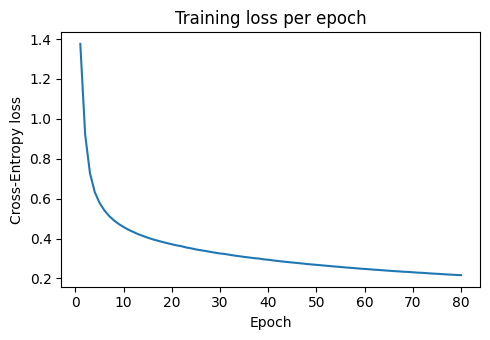

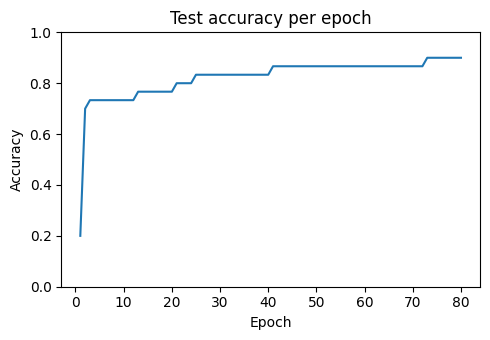

Final train acc: 0.95
Final test  acc: 0.9


In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# ----- Model -----
class SoftmaxLogisticRegression(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        # return raw logits
        return self.linear(x)

    @torch.no_grad()
    def predict_proba(self, x):
        logits = self.forward(x)
        return torch.softmax(logits, dim=1)  # <-- FIX 1

    @torch.no_grad()
    def predict(self, x):
        logits = self.forward(x)
        return torch.argmax(logits, dim=1)

criterion = nn.CrossEntropyLoss()              # <-- FIX 2

def accuracy(model, loader, device="cpu"):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model.predict(xb)
            correct += (pred == yb).sum().item()
            total += yb.numel()
    return correct / total

def train_model(model, train_loader, test_loader,
                lr=0.05, epochs=80, device="cpu"):
    model.to(device)
    opt = optim.SGD(model.parameters(), lr=lr)
    train_losses, test_accs = [], []

    for _ in range(epochs):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)               # logits: (B, C)
            loss = criterion(logits, yb)     # yb: (B,) class indices
            loss.backward()
            opt.step()
            running += loss.item() * yb.size(0)

        train_losses.append(running / len(train_loader.dataset))
        test_accs.append(accuracy(model, test_loader, device))

    return train_losses, test_accs

# ----- Instantiate & train -----
input_dim, num_classes = 4, 3
model = SoftmaxLogisticRegression(input_dim, num_classes)

# reuse train_loader / test_loader from Exercise 2; if you don't have them:
# train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=True)
# test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=32, shuffle=False)

loss_curve, acc_curve = train_model(model, train_loader, test_loader,
                                    lr=0.05, epochs=80)

# ----- Learning curves -----
plt.figure(figsize=(5,3.5))
plt.plot(range(1, len(loss_curve)+1), loss_curve)
plt.title("Training loss per epoch")
plt.xlabel("Epoch"); plt.ylabel("Cross-Entropy loss"); plt.tight_layout(); plt.show()

plt.figure(figsize=(5,3.5))
plt.plot(range(1, len(acc_curve)+1), acc_curve)
plt.title("Test accuracy per epoch")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.ylim(0,1); plt.tight_layout(); plt.show()

print("Final train acc:", accuracy(model, train_loader))
print("Final test  acc:", accuracy(model, test_loader))


###Exercise 5 (Optional): Logistic regression with gradient descent from scratch

This exercise aims to strengthen the understanding of the machine learning pipeline. Instead of PyTorch functions for iterative and batch training, we can use our own implementation for weather prediction that passes through the logistic regression model and computes the loss at each time.

We can start with the beginning of the pipeline and use the function for data preparation:

After loading the data set, we can do the train and test split with PyTorch random sampling utility. The **randperm** function will create a permutation of the input ordered indices according to a Uniform probability distribution.

In [ ]:
# 1. Shuffle the data set so original order of measurements are mixed and distributed
idx = torch.randperm(datatensor.shape[0])
datatensor_shuffled = datatensor[idx]

# 2. Find splitting point to separate training and testing data
len_traindata = int(datatensor.shape[0]*0.8)

traindata = datatensor_shuffled[0:len_traindata,:]
testdata = datatensor_shuffled[len_traindata::,:]

print("Train data has samples of size: ", traindata.shape)
print("Test data has samples of size: ", testdata.shape)

# 3. To-do: Extract input features (Columns 0, 1, 3, .., 8) and store in train_in
train_in = torch.cat([traindata[:,0:2], traindata[:,3::]], dim=1)
test_in = torch.cat([testdata[:,0:2], testdata[:,3::]], dim=1)
train_out = traindata[:,2] # we will use 3rd column as target prediction
test_out = testdata[:,2]


NameError: name 'datatensor' is not defined

Train accuracy: 0.9583
Test  accuracy: 0.9333


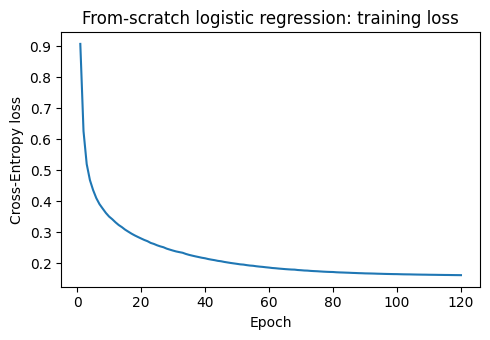

In [ ]:
# ====== From-scratch softmax logistic regression ======
import torch
import math
import matplotlib.pyplot as plt

# --- data ---
Xtr, ytr = X_train_t, y_train_t          # (N_train, D), (N_train,)
Xte, yte = X_test_t,  y_test_t           # (N_test,  D), (N_test,)
N, D     = Xtr.shape
C        = int(ytr.max().item() + 1)

# --- helpers ---
def softmax(z):
    # z: (B, C)
    zmax = z.max(dim=1, keepdim=True).values
    ez   = torch.exp(z - zmax)
    return ez / ez.sum(dim=1, keepdim=True)

def one_hot(y, C):
    # y: (B,)
    return torch.zeros(y.size(0), C, dtype=torch.float32).scatter_(1, y.view(-1,1), 1.0)

def cross_entropy(probs, y):
    # probs: (B, C), y: (B,)
    p = probs[torch.arange(y.size(0)), y.long()]
    return -torch.log(p + 1e-12).mean()

def accuracy(W, b, X, y):
    pred = (X @ W + b).argmax(dim=1)
    return (pred == y).float().mean().item()

# --- initialize params ---
g = torch.Generator().manual_seed(0)
W = torch.randn(D, C, generator=g) * 0.01
b = torch.zeros(C)

# --- hyperparams ---
epochs   = 120         # try 50–200
lr       = 0.2         # if loss wiggles, lower to 0.05–0.1
batch_sz = 32          # set to None for full-batch GD
lam      = 1e-3        # L2 weight decay (set 0 to disable)

loss_curve = []

# --- training loop (manual gradients) ---
for epoch in range(1, epochs+1):
    if batch_sz is None:                        # full-batch
        Xb, yb = Xtr, ytr
        probs  = softmax(Xb @ W + b)
        y_one  = one_hot(yb, C)
        loss   = cross_entropy(probs, yb) + 0.5*lam*(W*W).sum()/Xb.size(0)

        dlogits = (probs - y_one) / Xb.size(0)          # (B,C)
        grad_W  = Xb.t() @ dlogits + lam*W/Xb.size(0)   # (D,C)
        grad_b  = dlogits.sum(dim=0)                    # (C,)
        W -= lr * grad_W
        b -= lr * grad_b
        loss_curve.append(loss.item())
    else:                                              # mini-batch
        perm = torch.randperm(N)
        Xsh, ysh = Xtr[perm], ytr[perm]
        running = 0.0
        for i in range(0, N, batch_sz):
            Xb = Xsh[i:i+batch_sz]
            yb = ysh[i:i+batch_sz]
            probs  = softmax(Xb @ W + b)
            y_one  = one_hot(yb, C)
            loss   = cross_entropy(probs, yb) + 0.5*lam*(W*W).sum()/Xb.size(0)

            dlogits = (probs - y_one) / Xb.size(0)
            grad_W  = Xb.t() @ dlogits + lam*W/Xb.size(0)
            grad_b  = dlogits.sum(dim=0)
            W -= lr * grad_W
            b -= lr * grad_b
            running += loss.item() * Xb.size(0)
        loss_curve.append(running / N)

    # (optional) tiny cosine LR schedule for stability
    lr0 = 0.2
    lr  = 0.02 + 0.18 * (0.5 * (1 + math.cos(math.pi*epoch/epochs)))

# --- results ---
print("Train accuracy:", round(accuracy(W, b, Xtr, ytr), 4))
print("Test  accuracy:", round(accuracy(W, b, Xte, yte), 4))

plt.figure(figsize=(5,3.5))
plt.plot(range(1, len(loss_curve)+1), loss_curve)
plt.title("From-scratch logistic regression: training loss")
plt.xlabel("Epoch"); plt.ylabel("Cross-Entropy loss")
plt.tight_layout(); plt.show()


We will learn the optimal values for the parameters in our logistic function using the gradient descent algorithm. In order to complete the optimization, we need to compute the gradient of the function representing the model over the training examples.

Let's create a loop over which we will evaluate the gradient of the model on the examples and use the gradient value to update our parameters.

At each step, complete the missing parts using Python or PyTorch for mathematical functions and ensure all four steps of training are consistent. Check if you can train your model using gradient-descent.

In [ ]:
# Training loop without any Pytorch functions


Once we complete the training, we can use the model that learned to predict the rain for actual measurement:

In [ ]:
import matplotlib.pyplot as plt

# Use trained model to predict rain probability


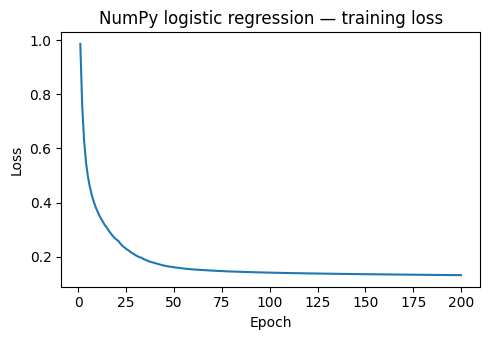

0.9666666666666667 0.9333333333333333


In [ ]:
# =========================
# Logistic Regression (NumPy)
# =========================
import numpy as np
import matplotlib.pyplot as plt

# If you currently have torch tensors from earlier:
# X_train = X_train_t.numpy(); y_train = y_train_t.numpy()
# X_test  = X_test_t.numpy();  y_test  = y_test_t.numpy()

# ---- utilities ----
def add_bias(X):
    # add a bias column of 1s
    return np.c_[X, np.ones((X.shape[0], 1))]

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    EZ = np.exp(Z)
    return EZ / EZ.sum(axis=1, keepdims=True)

def one_hot(y, C):
    Y = np.zeros((y.shape[0], C), dtype=float)
    Y[np.arange(y.shape[0]), y.astype(int)] = 1.0
    return Y

def ce_loss_binary(p, y):
    # p: (N,), y: (N,)
    eps = 1e-12
    return -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))

def ce_loss_multiclass(P, y):
    # P: (N,C) probabilities, y: (N,) int labels
    eps = 1e-12
    return -np.mean(np.log(P[np.arange(y.size), y.astype(int)] + eps))

# ---- main trainer ----
def train_logreg_numpy(X_train, y_train, X_test, y_test,
                       lr=0.1, epochs=200, lam=1e-3, minibatch=None):
    """
    If y has 2 unique values -> binary (sigmoid).
    Else -> multiclass (softmax).
    lam is L2 weight decay. minibatch = None means full-batch GD.
    """
    Xtr = add_bias(X_train)              # (N, D+1)
    Xte = add_bias(X_test)
    N, Dp1 = Xtr.shape
    classes = np.unique(y_train)
    binary = (classes.size == 2)
    C = 1 if binary else classes.size

    rng = np.random.default_rng(0)
    W = rng.normal(0, 0.01, size=(Dp1, C))  # (D+1, C); for binary we’ll squeeze later

    losses = []
    for epoch in range(1, epochs+1):
        # shuffle for minibatching
        idx = rng.permutation(N)
        Xtr_shuf, ytr_shuf = Xtr[idx], y_train[idx]

        # iterate either once (full-batch) or many minibatches
        total_loss = 0.0
        count_seen = 0
        bs = N if minibatch is None else minibatch

        for s in range(0, N, bs):
            Xb = Xtr_shuf[s:s+bs]
            yb = ytr_shuf[s:s+bs]
            m = Xb.shape[0]

            if binary:
                # forward
                z = Xb @ W    # (m,1)
                p = sigmoid(z).reshape(-1)  # (m,)
                loss = ce_loss_binary(p, yb) + 0.5*lam*np.sum(W*W)/m

                # gradients
                dZ = (p - yb).reshape(-1, 1) / m           # (m,1)
                grad_W = Xb.T @ dZ + (lam/m)*W             # (D+1,1)

            else:
                # forward
                Z = Xb @ W                  # (m,C)
                P = softmax(Z)              # (m,C)
                loss = ce_loss_multiclass(P, yb) + 0.5*lam*np.sum(W*W)/m

                # gradients
                Y1H = one_hot(yb, C)        # (m,C)
                dZ = (P - Y1H) / m          # (m,C)
                grad_W = Xb.T @ dZ + (lam/m)*W   # (D+1,C)

            # SGD step
            W -= lr * grad_W

            total_loss += loss * m
            count_seen += m

        losses.append(total_loss / count_seen)

        # simple cosine LR schedule (optional; helps stability)
        lr0 = lr
        lr = 0.02 + 0.98*lr0 * 0.5*(1 + np.cos(np.pi*epoch/epochs))

    # ---- evaluation ----
    if binary:
        p_tr = sigmoid(Xtr @ W).reshape(-1)
        p_te = sigmoid(Xte @ W).reshape(-1)
        yhat_tr = (p_tr >= 0.5).astype(int)
        yhat_te = (p_te >= 0.5).astype(int)
    else:
        P_tr = softmax(Xtr @ W)
        P_te = softmax(Xte @ W)
        yhat_tr = P_tr.argmax(axis=1)
        yhat_te = P_te.argmax(axis=1)

    acc_tr = (yhat_tr == y_train).mean()
    acc_te = (yhat_te == y_test).mean()

    # plot learning curve
    plt.figure(figsize=(5,3.5))
    plt.plot(range(1, len(losses)+1), losses)
    plt.title("NumPy logistic regression — training loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.tight_layout(); plt.show()

    return W, acc_tr, acc_te

# ===== run it =====
# Example (assuming you converted tensors to NumPy):
W, train_acc, test_acc = train_logreg_numpy(X_train, y_train, X_test, y_test,
                                             lr=0.1, epochs=200, lam=1e-3, minibatch=32)
print(train_acc, test_acc)


After ensuring your model works, you can extend your training loop for batch training (stochastic gradient descent) to improve its efficiency. Compare the two approaches and whether the accuracy is affected by exact vs. approximate gradient computation.

## Further exercises:

- [Google crash course on machine learning](https://developers.google.com/machine-learning/crash-course)
includes visual exercises like [experiments with hyper-parameters](https://developers.google.com/machine-learning/crash-course/fitter/graph)